# M11.11 — Final CNN evaluation

Evaluación final del predictor M11 sobre el test sintético congelado de 30 000
muestras de `M11_final_G1_500k`. La inferencia cal+test se ejecutó previamente en
la VM con `scripts/predict_cnn_hdf5.py`; este notebook es exclusivamente de análisis
local, sin GPU, reconstrucción del predictor ni lectura de señales.

Calibration queda reservado para Mondrian: aquí sólo se validan y desestandarizan
sus arrays para el workflow posterior, sin métricas ni ajuste sobre cal. Test no
se utiliza para seleccionar arquitectura, hiperparámetros ni corregir predicciones.
No se realiza Mondrian ni evaluación de eventos reales.

H1/L1/V1, 4096 Hz, 4 s, SEOBNRv4_opt, full_projection, GPS variable, dominio G1
con PSD empírica, SNR óptimo objetivo 10–25 en 30–512 Hz. La normalización ya fue
aplicada antes de generar las predicciones. Todas las métricas se calculan en
unidades físicas. M10 y M11 tienen tests distintos: comparación descriptiva,
no experimento causal pareado.

## 2. Imports y paths

In [1]:
from pathlib import Path
import sys
import json
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

root = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "src/paths.py").is_file()), None)

if root is None:
    raise RuntimeError("Abrir el notebook desde el repositorio cbc_pe.")

if str(root) not in sys.path:
    sys.path.insert(0, str(root))

from src.paths import resolve_project_root, resolve_data_root, resolve_processed_artifact

PROJECT_ROOT = resolve_project_root()
DATA_ROOT = resolve_data_root(config_data_root="/data/vserrano/cbc_pe_data")
DATASET_ID = "M11_final_G1_500k"
LABEL_NAMES = ["chirp_mass", "total_mass", "chi_eff"]
UNITS = {"chirp_mass": "Msun", "total_mass": "Msun", "chi_eff": "dimensionless"}
DATASET_PATH = resolve_processed_artifact(
    data_root=DATA_ROOT, dataset_id=DATASET_ID,
    file_name="m11_final_G1_500k_trainio.h5", allow_legacy_flat=False)
RESULTS_DIR = DATA_ROOT / "results" / DATASET_ID
FIGURES_DIR = RESULTS_DIR / "M11_11_final_cnn_evaluation" / "figures"
PREDICTIONS_PATH = RESULTS_DIR / "m11_final_G1_500k_cal_test_predictions_embeddings.npz"
ANALYSIS_DIR = FIGURES_DIR.parent

M10_RESULTS_DIR = DATA_ROOT / "results/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000"
M10_PREDICTIONS_PATH = M10_RESULTS_DIR / "m10_inputzscore_500k_cal_test_predictions_embeddings.npz"
M10_METRICS_PATH = M10_RESULTS_DIR / "m10_inputzscore_500k_evaluation/m10_500k_test_metrics_phys.csv"

print("DATA_ROOT:", DATA_ROOT)
print("Predicciones:", PREDICTIONS_PATH)
# Nombre verificado en configs/prediction/predict_m11_final_G1_500k_cal_test.json.
if not PREDICTIONS_PATH.is_file():
    raise FileNotFoundError(
        f"No se encuentra el NPZ de predicciones: {PREDICTIONS_PATH}. "
        "Copiar el artefacto generado en VM o editar PREDICTIONS_PATH/DATA_ROOT.")

DATA_ROOT: /data/vserrano/cbc_pe_data
Predicciones: /data/vserrano/cbc_pe_data/results/M11_final_G1_500k/m11_final_G1_500k_cal_test_predictions_embeddings.npz


## 3. Load prediction artifact

Se utilizan las claves reales de `predict_cnn_hdf5.py`, verificadas en el NPZ.
`allow_pickle=True` permite leer los diccionarios de provenance del artefacto
propio de confianza. Los embeddings permanecen en el archivo, sin uso aquí.
No se abren checkpoint, split ni scaler externos: su provenance se muestra desde
el NPZ. No se normalizan otra vez entradas ni labels.

In [2]:
def require(condition, message):
    if not condition:
        raise ValueError(message)

with np.load(PREDICTIONS_PATH, allow_pickle=True) as z:
    required = {"y_mean", "y_std", "label_names", "checkpoint_file", "dataset_path",
                "split_path", "label_stats_path", "model_config", "input_normalization",
                "available_splits", "pred_cal", "emb_cal", "y_cal", "idx_cal",
                "pred_test", "emb_test", "y_test", "idx_test"}
    require(required.issubset(z.files), f"Faltan claves: {sorted(required - set(z.files))}")
    label_names = z["label_names"].tolist()
    require(label_names == LABEL_NAMES, f"Orden de labels incorrecto: {label_names}")
    y_mean, y_std = z["y_mean"].copy(), z["y_std"].copy()
    idx_cal, idx_test = z["idx_cal"].copy(), z["idx_test"].copy()
    y_cal, pred_cal = z["y_cal"].copy(), z["pred_cal"].copy()
    y_test, pred_test = z["y_test"].copy(), z["pred_test"].copy()
    require(set(z["available_splits"].tolist()) == {"cal", "test"}, "Splits inesperados")
    provenance = {key: z[key].item() for key in
                  ("checkpoint_file", "dataset_path", "split_path", "label_stats_path",
                   "model_config", "input_normalization")}

require(y_mean.shape == y_std.shape == (3,), "Shape del scaler incorrecto")
require(np.isfinite(y_mean).all() and np.isfinite(y_std).all() and (y_std > 0).all(),
        "Scaler no finito o desviaciones no positivas")
for name, values in [("y_cal", y_cal), ("pred_cal", pred_cal),
                     ("y_test", y_test), ("pred_test", pred_test)]:
    require(values.shape == (30000, 3), f"Shape incorrecto: {name}")
    require(np.isfinite(values).all(), f"NaN/Inf: {name}")
for name, indices in [("cal", idx_cal), ("test", idx_test)]:
    require(indices.shape == (30000,) and np.issubdtype(indices.dtype, np.integer),
            f"Índices incorrectos: {name}")
    require(len(np.unique(indices)) == 30000, f"Índices repetidos: {name}")
    require(np.all((indices >= 0) & (indices < 500000)), f"Índices fuera de rango: {name}")
require(np.intersect1d(idx_cal, idx_test).size == 0, "Cal y test se solapan")
require(provenance["model_config"]["dataset_id"] == DATASET_ID, "Dataset del artefacto incorrecto")
require(provenance["model_config"]["label_names"] == LABEL_NAMES, "Labels de provenance incorrectos")
require(provenance["input_normalization"] == dict(enabled=False, already_normalized=True,
    mode="per_sample_per_detector_zscore", eps=1e-6), "Contrato de normalización inesperado")
print(json.dumps(provenance, indent=2))
display(pd.DataFrame({"label": LABEL_NAMES, "train_y_mean": y_mean, "train_y_std": y_std}))

{
  "checkpoint_file": "/data/vserrano/cbc_pe_data/models/checkpoints/M11_final_G1_500k/M11_final_G1_500k_SimpleCNN_ResidualDilated_M11_final_G1_inputzscore_resdilated_emb64_d124_train400k_MSELoss_seed123_checkpoint.pt",
  "dataset_path": "/data/vserrano/cbc_pe_data/processed/M11_final_G1_500k/m11_final_G1_500k_trainio.h5",
  "split_path": "/data/vserrano/cbc_pe_data/processed/M11_final_G1_500k/M11_final_G1_500k_splits_train400000_val40000_cal30000_test30000_seed123.npz",
  "label_stats_path": "/data/vserrano/cbc_pe_data/processed/M11_final_G1_500k/M11_final_G1_500k_label_stats_train_only_train400000_val40000_cal30000_test30000_seed123.npz",
  "model_config": {
    "architecture": "SimpleCNN_ResidualDilated",
    "class_name": "SimpleCNN_ResidualDilated",
    "dataset_id": "M11_final_G1_500k",
    "dataset_format": "hdf5",
    "dataset_path": "/data/vserrano/cbc_pe_data/processed/M11_final_G1_500k/m11_final_G1_500k_trainio.h5",
    "split_path": "/data/vserrano/cbc_pe_data/processed/M1

,label,train_y_mean,train_y_std
0,chirp_mass,37.463547,16.508060
1,total_mass,94.985977,34.703293
2,chi_eff,-0.000219,0.440338


## 4. Inverse transform

`y_cal`, `pred_cal`, `y_test` y `pred_test` están estandarizados según el script de
predicción. Se aplica `physical = standardized * y_std + y_mean`, igual que M10.
Los arrays físicos de cal sólo quedan disponibles para el workflow posterior;
todos los análisis siguientes se limitan a test.

In [3]:
def inverse_standardize(values, mean, std):
    return values * std + mean

y_cal_phys = inverse_standardize(y_cal, y_mean, y_std)
pred_cal_phys = inverse_standardize(pred_cal, y_mean, y_std)
y_test_phys = inverse_standardize(y_test, y_mean, y_std)
pred_test_phys = inverse_standardize(pred_test, y_mean, y_std)
for values in (y_cal_phys, pred_cal_phys, y_test_phys, pred_test_phys):
    require(values.shape == (30000, 3) and np.isfinite(values).all(), "Inverse transform inválido")
y_true_phys = y_test_phys.astype(np.float64)
y_pred_phys = pred_test_phys.astype(np.float64)
residual = y_pred_phys - y_true_phys
test_idx = idx_test

## 5. Prediction sanity

Estadísticas físicas de test; desviaciones con ddof=0.

In [4]:
require(y_true_phys.shape == y_pred_phys.shape == (30000, 3), "Shape test incorrecto")
require(np.isfinite(y_true_phys).all() and np.isfinite(y_pred_phys).all(), "Test con NaN/Inf")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
display(pd.DataFrame({"label": LABEL_NAMES,
    "true_min": y_true_phys.min(axis=0), "true_max": y_true_phys.max(axis=0),
    "pred_min": y_pred_phys.min(axis=0), "pred_max": y_pred_phys.max(axis=0),
    "true_mean": y_true_phys.mean(axis=0), "pred_mean": y_pred_phys.mean(axis=0),
    "true_std": y_true_phys.std(axis=0), "pred_std": y_pred_phys.std(axis=0)}))

def save_table(frame, name):
    frame.to_csv(ANALYSIS_DIR / f"{name}.csv", index=False)
    display(frame)

def finish_figure(fig, name):
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f"{name}.png", dpi=200)
    plt.show()
    plt.close(fig)

,label,true_min,true_max,pred_min,pred_max,true_mean,pred_mean,true_std,pred_std
0,chirp_mass,4.498730,78.248093,6.475983,73.833618,37.461688,37.616105,16.493347,14.708843
1,total_mass,10.335785,179.766953,13.986954,170.627808,95.063919,95.397854,34.582361,31.274277
2,chi_eff,-0.996428,0.996464,-0.855331,0.906316,-0.003891,-0.008509,0.440409,0.381510


## 6. Métricas globales

Se reproduce la función NumPy/pandas `regression_metrics` de `src/models/evaluate.py`
localmente para evitar la dependencia de PyTorch que importa ese módulo. Mismas
fórmulas y columnas; sin modificar utilidades compartidas. Residual = pred − true;
residual std usa ddof=0. Todas las métricas usan unidades físicas de test.

In [5]:
def regression_metrics(y_true, y_pred, label_names, split_name="test"):
    """
    Computes regression metrics per label.

    Parameters
    ----------
    y_true : np.ndarray
        True labels. Shape (N, n_labels).

    y_pred : np.ndarray
        Predicted labels. Shape (N, n_labels).

    label_names : list[str]
        Names of the target labels.

    split_name : str
        Name of the evaluated split: train, val, cal, test.

    Returns
    -------
    pd.DataFrame
        One row per label with regression metrics.
    """

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    residual = y_pred - y_true
    abs_error = np.abs(residual)

    mse = np.mean(residual ** 2, axis=0)
    rmse = np.sqrt(mse)
    mae = np.mean(abs_error, axis=0)
    bias = np.mean(residual, axis=0)
    median_abs_error = np.median(abs_error, axis=0)
    residual_std = np.std(residual, axis=0)

    ss_res = np.sum(residual ** 2, axis=0)
    ss_tot = np.sum((y_true - np.mean(y_true, axis=0)) ** 2, axis=0)
    r2 = 1.0 - ss_res / ss_tot

    rows = []

    for j, label in enumerate(label_names):
        rows.append({
            "split": split_name,
            "label": label,
            "MSE": mse[j],
            "RMSE": rmse[j],
            "MAE": mae[j],
            "bias": bias[j],
            "median_abs_error": median_abs_error[j],
            "residual_std": residual_std[j],
            "R2": r2[j],
        })

    return pd.DataFrame(rows)

metrics = regression_metrics(y_true_phys, y_pred_phys, LABEL_NAMES)[
    ["label", "RMSE", "MAE", "bias", "residual_std", "R2"]]

save_table(metrics, "test_metrics_physical")

,label,RMSE,MAE,bias,residual_std,R2
0,chirp_mass,5.768810,3.924969,0.154418,5.766742,0.877664
1,total_mass,10.408432,7.403433,0.333935,10.403074,0.909414
2,chi_eff,0.190098,0.142680,-0.004617,0.190042,0.813688


## 7. Comparación con M10

Prioridad: predicciones test M10 → CSV físico de su notebook → RMSE de referencia
aportados (artifact-backed, pero no verificados localmente si faltan ambos archivos).
Para M10 sólo se leen predicciones de test. Cada modelo usa **su propio scaler train-only**.
Las rutas proceden de `notebooks/10_m10_inputzscore_500k_evaluation.ipynb`.
El notebook `03_cnn_evaluation_500k_M08_vs_M09_final_clean_timecoords_fixed.ipynb`
no se encontró en este checkout.

Igual definición de métricas, orden de labels y unidades. Esto no demuestra que
los tests, fuentes, ruido o contextos de señal sean iguales: no se calculan deltas
por muestra ni se atribuye causalidad a los deltas agregados. La referencia M10
se lee sin modificar sus artefactos. Delta negativo significa menor RMSE de M11;
relative delta es una fracción, no porcentaje.

In [6]:
if M10_PREDICTIONS_PATH.is_file():

    with np.load(M10_PREDICTIONS_PATH, allow_pickle=False) as z:

        assert z["label_names"].tolist() == LABEL_NAMES

        m10_mean, m10_std = z["y_mean"], z["y_std"]

        assert m10_mean.shape == m10_std.shape == (3,)
        assert np.isfinite(m10_mean).all() and np.isfinite(m10_std).all() and (m10_std > 0).all()

        # Convención de inverse transform del notebook M10 original.
        m10_true = inverse_standardize(z["y_test"], m10_mean, m10_std).astype(np.float64)
        m10_pred = inverse_standardize(z["pred_test"], m10_mean, m10_std).astype(np.float64)

    assert m10_true.shape == m10_pred.shape == (30000, 3)
    assert np.isfinite(m10_true).all() and np.isfinite(m10_pred).all()

    m10_rmse = regression_metrics(m10_true, m10_pred, LABEL_NAMES).set_index("label")["RMSE"]
    m10_source = str(M10_PREDICTIONS_PATH)

elif M10_METRICS_PATH.is_file():
    reference = pd.read_csv(M10_METRICS_PATH).set_index("label")

    assert reference.index.is_unique and set(reference.index) == set(LABEL_NAMES)

    m10_rmse = reference["rmse"]
    m10_source = str(M10_METRICS_PATH)

else:
    m10_rmse = pd.Series([4.949937, 9.369734, 0.186741], index=LABEL_NAMES)
    m10_source = "RMSE artifact-backed aportados; artefactos no disponibles localmente"

    print("AVISO:", m10_source)

comparison = metrics[["label", "RMSE"]].rename(columns={"RMSE": "M11_RMSE"})
comparison["M10_RMSE"] = comparison.label.map(m10_rmse)

assert np.isfinite(comparison["M10_RMSE"]).all() and (comparison["M10_RMSE"] > 0).all()

comparison["delta_RMSE"] = comparison["M11_RMSE"] - comparison["M10_RMSE"]
comparison["relative_delta"] = comparison["delta_RMSE"] / comparison["M10_RMSE"]
comparison = comparison[["label", "M10_RMSE", "M11_RMSE", "delta_RMSE", "relative_delta"]]

print("M10 source:", m10_source)

save_table(comparison, "m10_m11_rmse_comparison")

(ANALYSIS_DIR / "m10_reference.json").write_text(json.dumps({"source": m10_source,
    "comparison": "aggregate performance on distinct frozen test datasets"}, indent=2))

M10 source: /data/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/m10_inputzscore_500k_cal_test_predictions_embeddings.npz


,label,M10_RMSE,M11_RMSE,delta_RMSE,relative_delta
0,chirp_mass,4.949937,5.768810,0.818873,0.165431
1,total_mass,9.369734,10.408432,1.038698,0.110857
2,chi_eff,0.186741,0.190098,0.003357,0.017976


230

## 8. Predicted vs true

Una figura por label; hexbin con escala logarítmica de conteos y línea identidad.

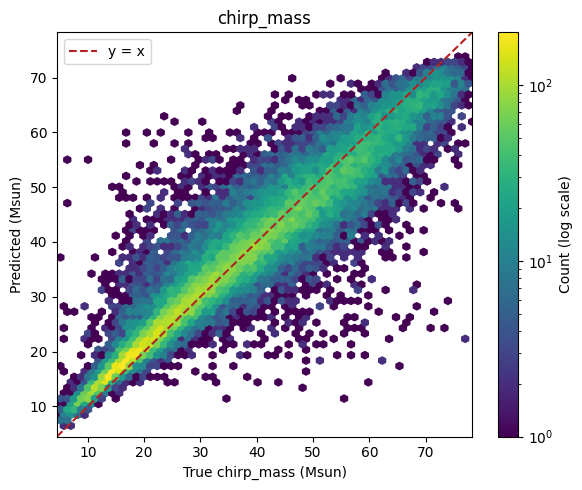

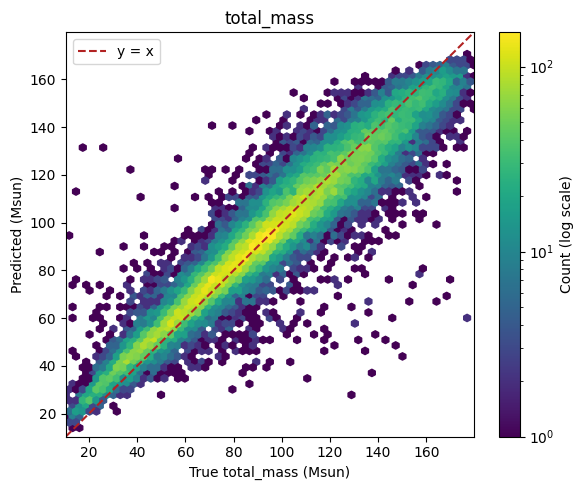

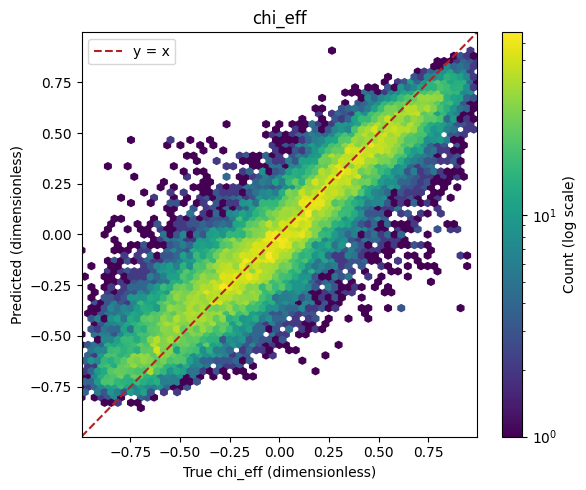

In [7]:
for j, label in enumerate(LABEL_NAMES):
    true, pred = y_true_phys[:, j], y_pred_phys[:, j]
    limits = [min(true.min(), pred.min()), max(true.max(), pred.max())]
    fig, ax = plt.subplots(figsize=(6, 5))
    density = ax.hexbin(true, pred, gridsize=60, bins="log", mincnt=1, cmap="viridis")
    ax.plot(limits, limits, "--", color="firebrick", label="y = x")
    ax.set(xlabel=f"True {label} ({UNITS[label]})", ylabel=f"Predicted ({UNITS[label]})",
           title=label, xlim=limits, ylim=limits)
    ax.legend()
    fig.colorbar(density, ax=ax, label="Count (log scale)")
    finish_figure(fig, f"predicted_vs_true_{label}")

## 9. Residual vs true

Residual positivo: sobreestimación; negativo: subestimación.

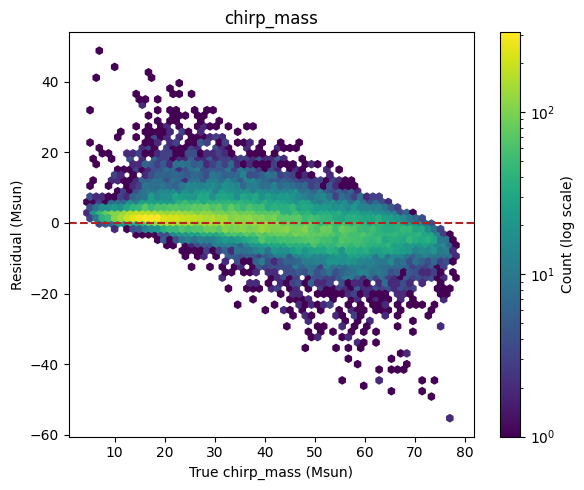

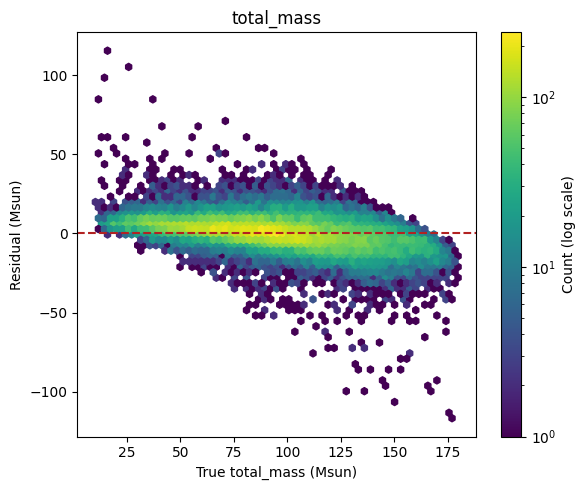

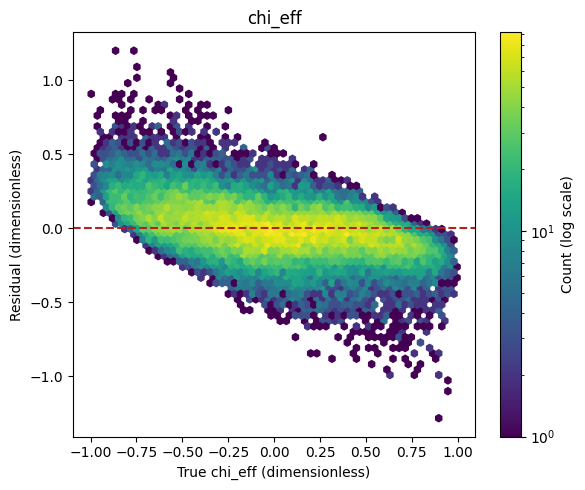

In [8]:
for j, label in enumerate(LABEL_NAMES):
    fig, ax = plt.subplots(figsize=(6, 5))
    density = ax.hexbin(y_true_phys[:, j], residual[:, j], gridsize=60,
                        bins="log", mincnt=1, cmap="viridis")
    ax.axhline(0, linestyle="--", color="firebrick")
    ax.set(xlabel=f"True {label} ({UNITS[label]})", ylabel=f"Residual ({UNITS[label]})", title=label)
    fig.colorbar(density, ax=ax, label="Count (log scale)")
    finish_figure(fig, f"residual_vs_true_{label}")

## 10. Métricas condicionadas al valor verdadero

Diez bins por cuantiles de truth, sin seleccionar parámetros del modelo. Si hay
bordes repetidos se reducen explícitamente los bins, sin separar artificialmente
valores idénticos. Se muestran conteos y límites; x es la media de truth del bin.

,label,bin,left,right,center,count,RMSE,MAE,bias
0,chirp_mass,0,4.498730,16.425760,12.824794,3000,4.328163,2.819798,2.780938
1,chirp_mass,1,16.425760,21.397372,18.907422,3000,5.176893,3.033853,2.812688
2,chirp_mass,2,21.397372,26.279853,23.836401,3000,5.213420,3.229173,2.555265
3,chirp_mass,3,26.279853,31.225661,28.761249,3000,5.465064,3.551277,2.512394
4,chirp_mass,4,31.225661,36.256931,33.704363,3000,5.164840,3.597238,1.679818
5,chirp_mass,5,36.256931,41.287415,38.760000,3000,5.053564,3.617568,0.699686
6,chirp_mass,6,41.287415,46.828349,44.000401,3000,5.432557,4.007089,-0.486188
7,chirp_mass,7,46.828349,53.222696,49.922492,3000,6.077468,4.501058,-2.196654
8,chirp_mass,8,53.222696,60.922143,56.985681,3000,7.115290,5.256634,-3.707052
9,chirp_mass,9,60.922143,78.248093,66.914075,3000,7.805256,5.636004,-5.106718


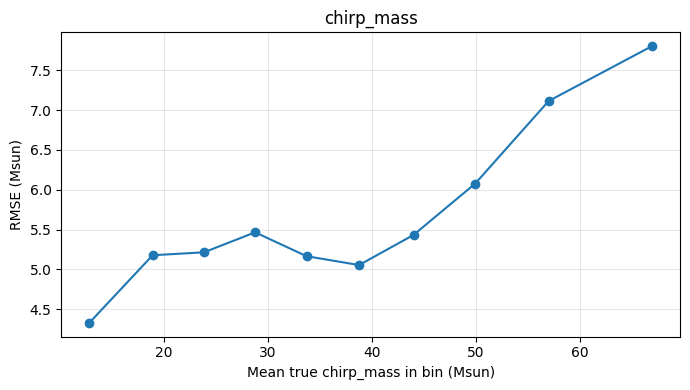

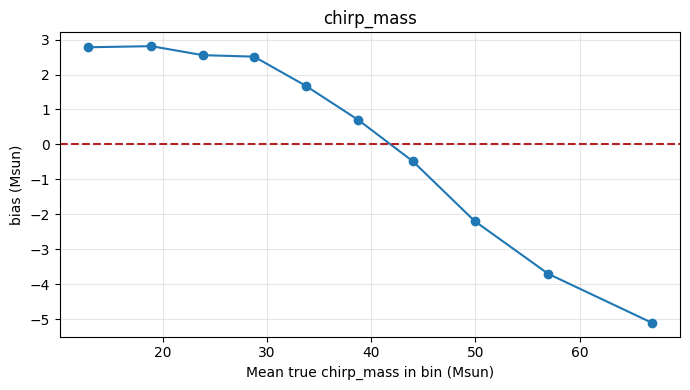

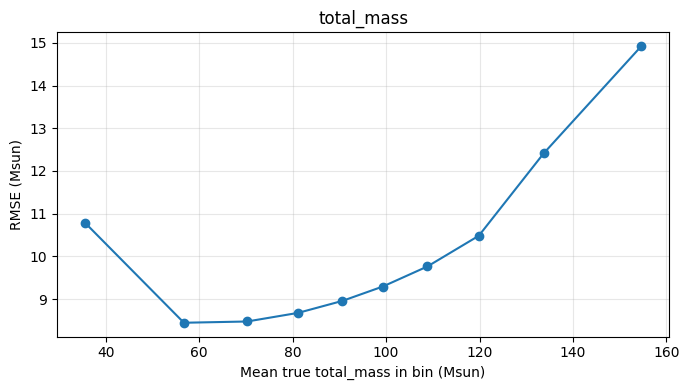

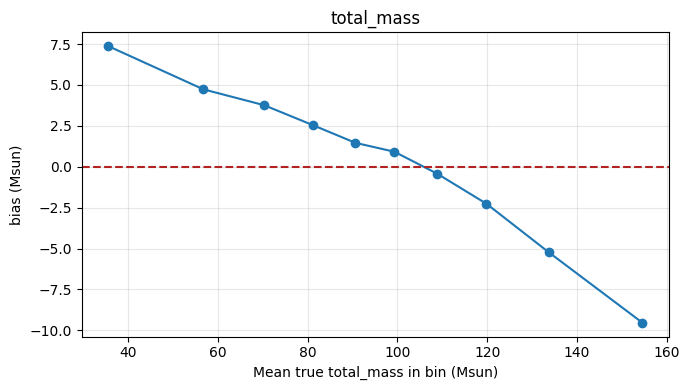

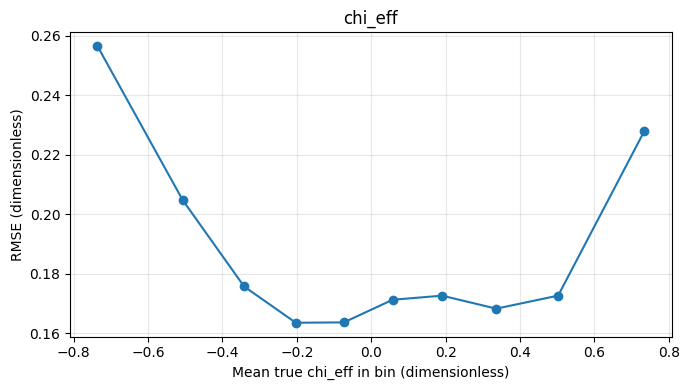

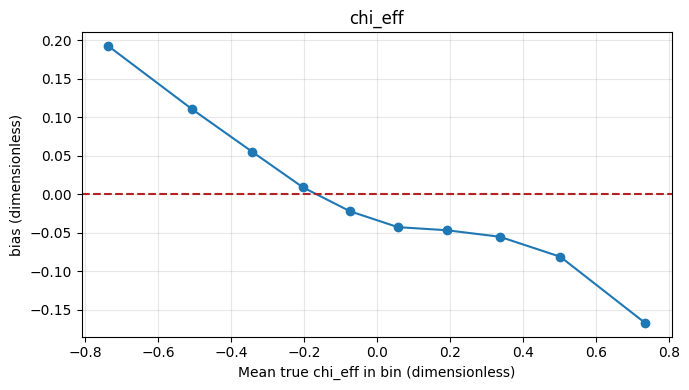

In [9]:
def bin_row(errors):
    if len(errors) == 0:
        return dict(count=0, RMSE=np.nan, MAE=np.nan, bias=np.nan)
    return dict(count=len(errors), RMSE=np.sqrt(np.mean(errors ** 2)),
                MAE=np.mean(np.abs(errors)), bias=np.mean(errors))

rows = []

for j, label in enumerate(LABEL_NAMES):
    true = y_true_phys[:, j]
    codes, edges = pd.qcut(true, q=10, labels=False, retbins=True, duplicates="drop")
    if len(edges) != 11:
        print(f"AVISO {label}: {len(edges) - 1} bins por bordes repetidos")
    for b in range(len(edges) - 1):
        mask = codes == b
        rows.append(dict(label=label, bin=b, left=edges[b], right=edges[b+1],
                         center=true[mask].mean(), **bin_row(residual[mask, j])))

true_bins = pd.DataFrame(rows)

save_table(true_bins, "metrics_by_true_quantile")

for label in LABEL_NAMES:
    table = true_bins[true_bins.label == label]
    for metric in ("RMSE", "bias"):
        fig, ax = plt.subplots(figsize=(7, 4))
        ax.plot(table.center, table[metric], "o-")
        if metric == "bias":
            ax.axhline(0, linestyle="--", color="firebrick")
        ax.set(xlabel=f"Mean true {label} in bin ({UNITS[label]})",
               ylabel=f"{metric} ({UNITS[label]})", title=label)
        ax.grid(alpha=0.3)
        finish_figure(fig, f"{metric}_vs_true_bin_{label}")

## 11. Regression to the mean

Ajuste descriptivo `pred = intercept + slope * true` por mínimos cuadrados.
Ideal: intercept=0, slope=1, std(pred)/std(true)=1. No se corrigen las predicciones;
estos números no sustituyen los diagnósticos condicionados ni prueban causalidad.

In [10]:
rows = []

for j, label in enumerate(LABEL_NAMES):
    true, pred = y_true_phys[:, j], y_pred_phys[:, j]
    if np.std(true) == 0:
        raise ValueError(f"Truth constante: {label}")
    intercept, slope = np.linalg.lstsq(np.column_stack([np.ones(len(true)), true]), pred, rcond=None)[0]
    rows.append(dict(label=label, intercept=intercept, slope=slope,
                     std_ratio=np.std(pred) / np.std(true)))

save_table(pd.DataFrame(rows), "regression_to_mean")

,label,intercept,slope,std_ratio
0,chirp_mass,6.278150,0.836533,0.891805
1,total_mass,13.293932,0.863671,0.904342
2,chi_eff,-0.005465,0.782103,0.866261


## 12. Metadata ligera desde HDF5

Sólo se leen campos 1D disponibles en los índices test. Nunca se leen señales.
Campos verificados en el artefacto real: source_id, source_index, final_network_snr,
target_network_snr, mass_1, mass_2 y chi_eff. La selección directa requiere índices
crecientes: si el NPZ no viene ordenado, se ordena únicamente la selección y se
restaura el orden original para conservar la alineación con las predicciones.
Si falta el HDF5, los análisis independientes de metadata siguen disponibles.

In [11]:
metadata = {}
fields = ("source_id", "source_index", "final_network_snr", "target_network_snr",
          "mass_1", "mass_2", "chi_eff")
if not DATASET_PATH.is_file():
    print(f"AVISO: HDF5 no disponible: {DATASET_PATH}; se omite metadata.")
else:
    order = np.argsort(test_idx)
    sorted_idx = test_idx[order]
    restore_order = np.argsort(order)
    with h5py.File(DATASET_PATH, "r") as h:
        require(h.attrs.get("experiment_id") == DATASET_ID, "HDF5 de otro dataset")
        require(h.attrs.get("labels") == ",".join(LABEL_NAMES), "Labels del HDF5 incorrectos")
        available = [field for field in fields if field in h
                     and isinstance(h[field], h5py.Dataset) and h[field].ndim == 1]
        print("Metadata 1D disponible:", available)
        for field in fields:
            if field not in available:
                print("Metadata no disponible:", field)
                continue
            require(h[field].shape == (500000,), f"Shape metadata: {field}")
            if np.all(np.diff(test_idx) > 0):
                values = h[field][test_idx]
            else:
                values = h[field][sorted_idx][restore_order]
            if values.dtype.kind in "OS":
                values = np.asarray([v.decode() if isinstance(v, bytes) else str(v) for v in values])
            else:
                require(np.isfinite(values).all(), f"Metadata no finita: {field}")
            metadata[field] = values
        if "final_network_snr" in metadata:
            require(h.attrs.get("snr_low_frequency_cutoff") == 30.0
                    and h.attrs.get("snr_high_frequency_cutoff") == 512.0, "Banda SNR inesperada")

Metadata 1D disponible: ['source_id', 'source_index', 'final_network_snr', 'target_network_snr', 'mass_1', 'mass_2', 'chi_eff']


## 13. Performance vs SNR

Campo verificado: `final_network_snr` (SNR óptimo final, no SNR observado en ruido).
Intervalos [10,12.5), …, [22.5,25], incluyendo 25 en el último. Se informa de muestras
fuera de rango: no se recortan ni se reasignan. Los bins vacíos quedan como NaN.
Sin metadata en el HDF5, esta sección se omite con aviso; no se fabrican valores.

`final_network_snr` es el SNR óptimo alcanzado tras reescalar distancia con PSD
empírica, según `scripts/generate_m11_final_G1.py`; no es el SNR observado
en la realización ruidosa. No se sustituye por target_network_snr si falta.

SNR min/max: 10.001519871403064 24.9996386898949
Fuera de [10,25]: 0


,label,left,right,center,count,RMSE,MAE,bias
0,chirp_mass,10.0,12.5,11.25,5034,7.920882,5.534133,-0.007537
1,chirp_mass,12.5,15.0,13.75,5034,6.609982,4.610422,0.197617
2,chirp_mass,15.0,17.5,16.25,4978,5.713511,3.988509,0.247114
3,chirp_mass,17.5,20.0,18.75,4939,5.120122,3.538002,0.147327
4,chirp_mass,20.0,22.5,21.25,5064,4.265831,3.053344,0.167172
5,chirp_mass,22.5,25.0,23.75,4951,3.980914,2.805546,0.175990
6,total_mass,10.0,12.5,11.25,5034,14.658759,10.682009,-0.234782
7,total_mass,12.5,15.0,13.75,5034,11.941546,8.775706,0.318537
8,total_mass,15.0,17.5,16.25,4978,9.961887,7.370762,0.444198
9,total_mass,17.5,20.0,18.75,4939,9.008654,6.506021,0.386633


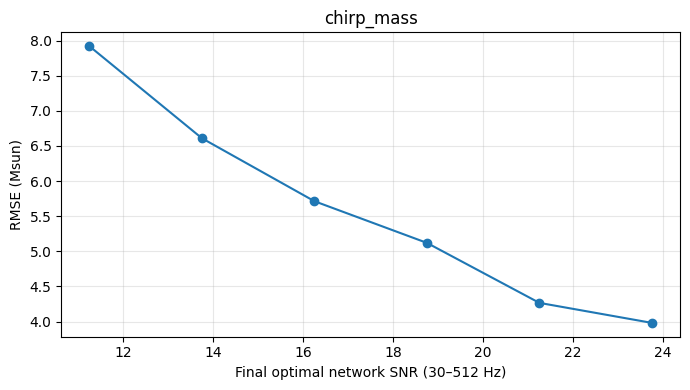

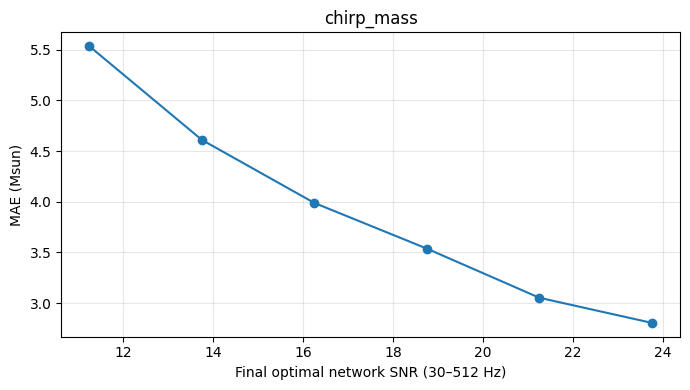

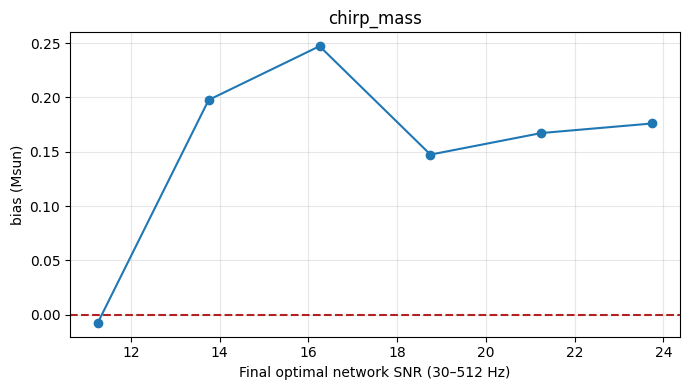

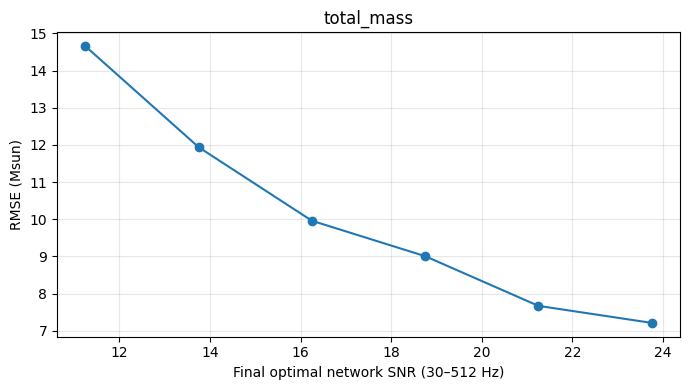

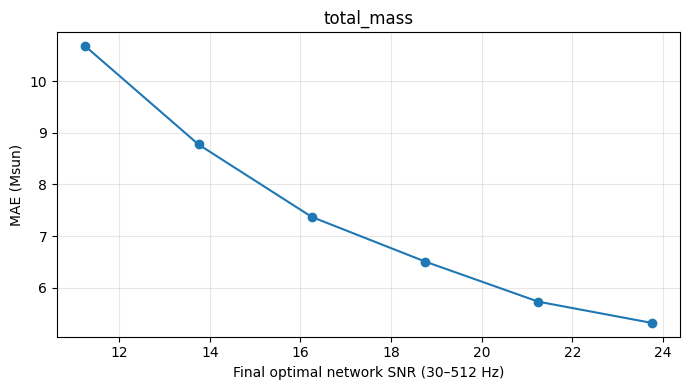

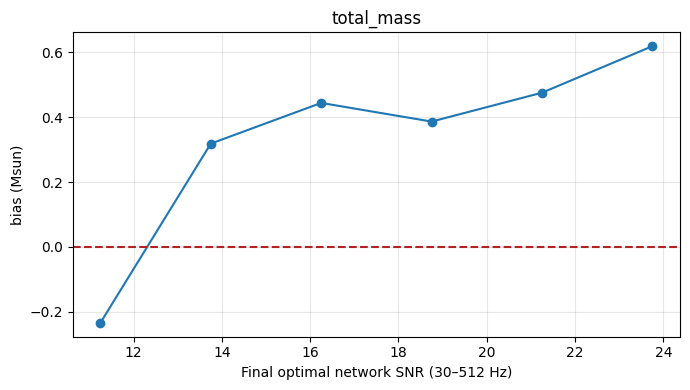

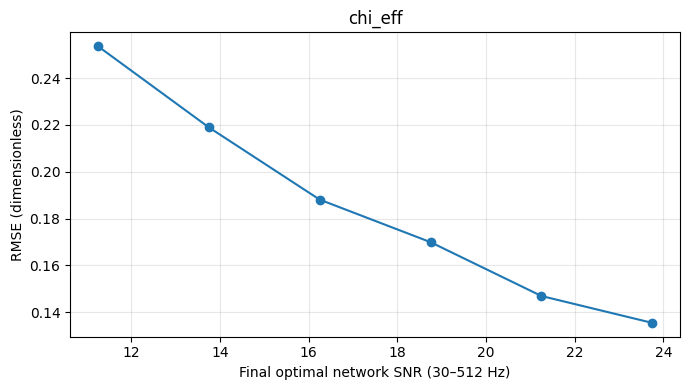

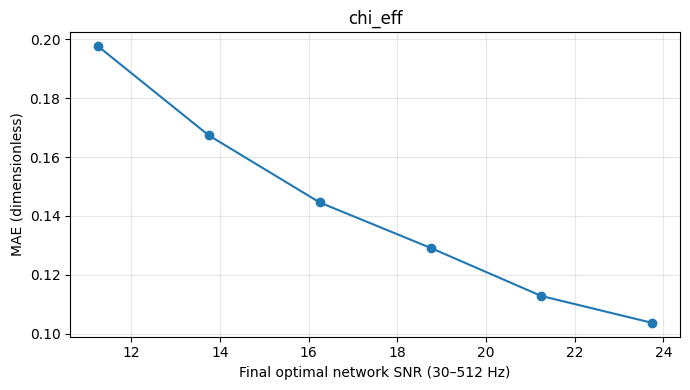

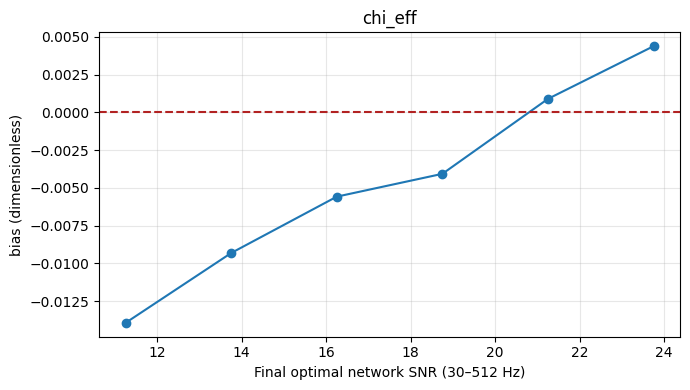

In [12]:
snr = metadata.get("final_network_snr")

if snr is None:
    print("AVISO: Metadata sin final_network_snr; evaluación por SNR no disponible.")

else:
    edges = np.array([10, 12.5, 15, 17.5, 20, 22.5, 25])

    print("SNR min/max:", snr.min(), snr.max())
    print("Fuera de [10,25]:", np.count_nonzero((snr < 10) | (snr > 25)))

    rows = []

    for j, label in enumerate(LABEL_NAMES):
        for b, (left, right) in enumerate(zip(edges[:-1], edges[1:])):
            mask = (snr >= left) & ((snr <= right) if b == len(edges)-2 else (snr < right))
            rows.append(dict(label=label, left=left, right=right, center=(left+right)/2,
                             **bin_row(residual[mask, j])))

    snr_metrics = pd.DataFrame(rows)

    save_table(snr_metrics, "metrics_by_final_network_snr")

    for label in LABEL_NAMES:
        table = snr_metrics[snr_metrics.label == label]

        for metric in ("RMSE", "MAE", "bias"):
            fig, ax = plt.subplots(figsize=(7, 4))
            ax.plot(table.center, table[metric], "o-")
            if metric == "bias":
                ax.axhline(0, linestyle="--", color="firebrick")
            ax.set(xlabel="Final optimal network SNR (30–512 Hz)",
                   ylabel=f"{metric} ({UNITS[label]})", title=label)
            ax.grid(alpha=0.3)
            finish_figure(fig, f"{metric}_vs_snr_{label}")

## 14. Error relativo para masas

(pred − true)/true y su valor absoluto. No se aplica a chi_eff.

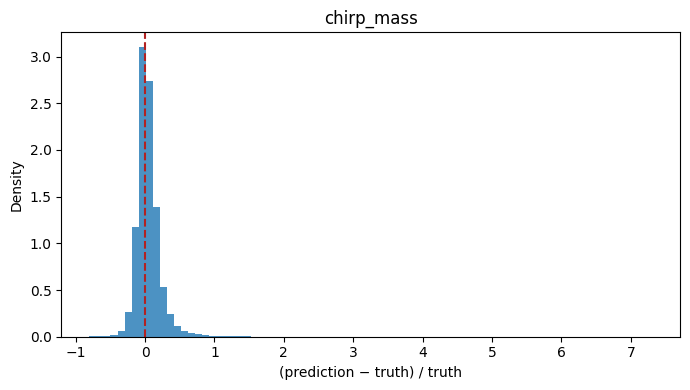

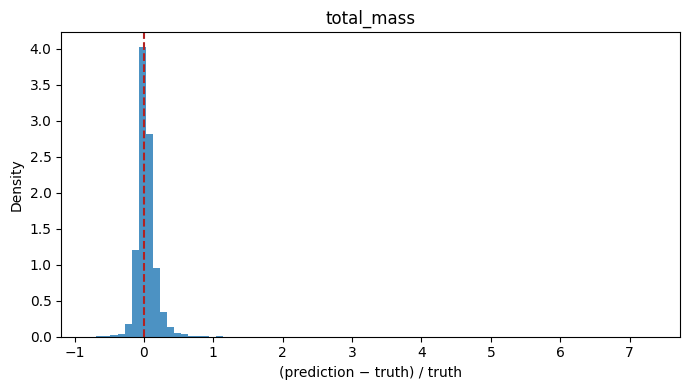

,label,mean_rel_error,mean_abs_rel_error,median_abs_rel_error
0,chirp_mass,0.045560,0.121784,0.081785
1,total_mass,0.031388,0.093084,0.061783


In [13]:
rows = []

relative_errors = pd.DataFrame({"dataset_index": test_idx})

for j, label in enumerate(LABEL_NAMES[:2]):
    assert (y_true_phys[:, j] > 0).all(), "Masa verdadera no positiva"
    rel = residual[:, j] / y_true_phys[:, j]
    relative_errors[f"{label}_rel_error"] = rel
    relative_errors[f"{label}_abs_rel_error"] = np.abs(rel)
    rows.append(dict(label=label, mean_rel_error=rel.mean(),
                     mean_abs_rel_error=np.abs(rel).mean(),
                     median_abs_rel_error=np.median(np.abs(rel))))
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(rel, bins=80, density=True, alpha=0.8)
    ax.axvline(0, linestyle="--", color="firebrick")
    ax.set(xlabel="(prediction − truth) / truth", ylabel="Density", title=label)
    finish_figure(fig, f"relative_error_{label}")

relative_errors.to_csv(ANALYSIS_DIR / "mass_relative_errors.csv", index=False)

save_table(pd.DataFrame(rows), "mass_relative_error_summary")

## 15. Distribuciones de residuales

Cuantiles empíricos e histogramas; no se presupone gaussianidad.

,label,q05,q16,median,q84,q95
0,chirp_mass,-8.711532,-4.388898,0.573112,4.005096,8.705075
1,total_mass,-16.258869,-8.156068,1.071062,8.514174,14.885821
2,chi_eff,-0.303703,-0.169831,-0.008217,0.163981,0.305130


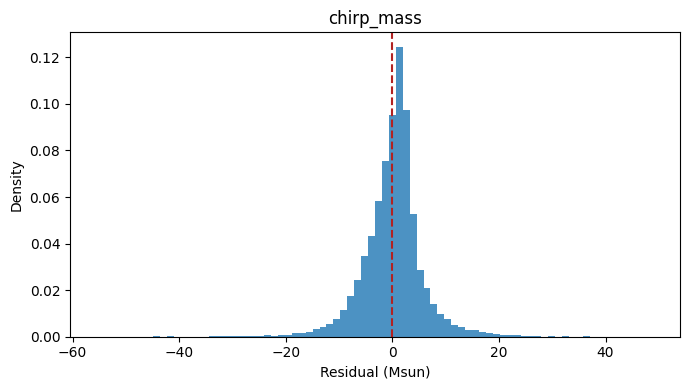

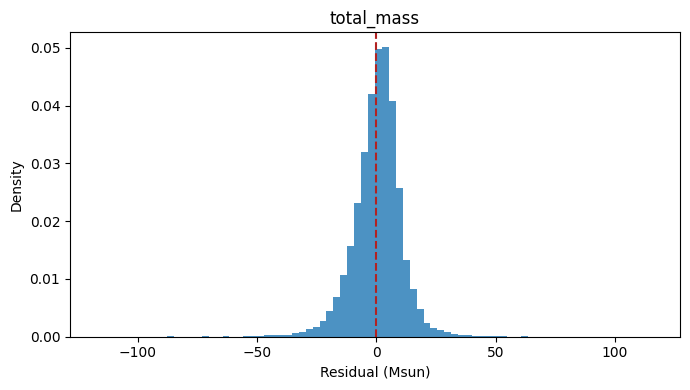

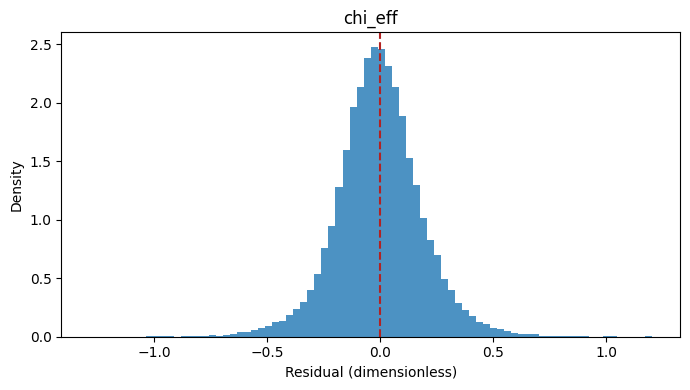

In [14]:
quantiles = pd.DataFrame(np.quantile(residual, [0.05, 0.16, 0.5, 0.84, 0.95], axis=0).T,
                         columns=["q05", "q16", "median", "q84", "q95"])

quantiles.insert(0, "label", LABEL_NAMES)

save_table(quantiles, "residual_quantiles")

for j, label in enumerate(LABEL_NAMES):
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(residual[:, j], bins=80, density=True, alpha=0.8)
    ax.axvline(0, linestyle="--", color="firebrick")
    ax.set(xlabel=f"Residual ({UNITS[label]})", ylabel="Density", title=label)
    finish_figure(fig, f"residual_distribution_{label}")

## 16. Casos extremos

Top 20 por |residual| de cada label; orden estable para empates. Metadata conservada
por índice de dataset y source ID cuando existe. La columna `chi_eff` aquí es
metadata física de la fuente. Inspección descriptiva: no se excluyen casos del test.

In [15]:
for j, label in enumerate(LABEL_NAMES):

    order = np.argsort(-np.abs(residual[:, j]), kind="stable")[:20]

    table = pd.DataFrame({"dataset_index": test_idx[order],
        "truth": y_true_phys[order, j], "prediction": y_pred_phys[order, j],
        "residual": residual[order, j], "abs_residual": np.abs(residual[order, j])})

    for field in ("source_id", "source_index", "final_network_snr", "target_network_snr",
                  "mass_1", "mass_2", "chi_eff"):
        if field in metadata:
            table[field] = metadata[field][order]
        else:
            print(f"{label}: metadata {field} no disponible")

    print(label)

    save_table(table, f"extreme_cases_{label}")

chirp_mass


,dataset_index,truth,prediction,residual,abs_residual,source_id,source_index,final_network_snr,target_network_snr,mass_1,mass_2,chi_eff
0,499007,77.183891,21.909977,-55.273914,55.273914,M11FINAL_G1_SRC_499007,499007,23.665844,23.665844,89.300549,88.026962,0.168058
1,493740,76.720016,21.988754,-54.731262,54.731262,M11FINAL_G1_SRC_493740,493740,17.708197,17.708197,89.098509,87.170463,0.553660
2,480246,73.238205,24.280624,-48.957581,48.957581,M11FINAL_G1_SRC_480246,480246,10.061788,10.061788,84.237815,84.019566,0.624168
3,490344,6.679579,55.454323,48.774744,48.774744,M11FINAL_G1_SRC_490344,490344,12.542966,12.542966,10.935436,5.509179,0.280030
4,478750,65.404930,17.198042,-48.206888,48.206888,M11FINAL_G1_SRC_478750,478750,11.631474,11.631474,83.301662,67.902377,0.293094
5,471948,71.238274,23.937519,-47.300755,47.300755,M11FINAL_G1_SRC_471948,471948,10.898872,10.898872,84.830517,78.958406,-0.222572
6,490477,59.796131,14.070492,-45.725639,45.725639,M11FINAL_G1_SRC_490477,490477,13.644587,13.644587,68.787050,68.588554,0.937475
7,477246,73.661270,28.826126,-44.835144,44.835144,M11FINAL_G1_SRC_477246,477246,12.222781,12.222781,84.910928,84.319473,-0.047299
8,475540,9.972706,54.591576,44.618870,44.618870,M11FINAL_G1_SRC_475540,475540,11.743655,11.743655,19.986002,6.928243,0.180993
9,491267,55.533722,11.049376,-44.484346,44.484346,M11FINAL_G1_SRC_491267,491267,10.275636,10.275636,68.509966,59.457626,0.507098


total_mass


,dataset_index,truth,prediction,residual,abs_residual,source_id,source_index,final_network_snr,target_network_snr,mass_1,mass_2,chi_eff
0,499007,177.327515,60.452278,-116.875237,116.875237,M11FINAL_G1_SRC_499007,499007,23.665844,23.665844,89.300549,88.026962,0.168058
1,490344,16.444618,132.103455,115.658836,115.658836,M11FINAL_G1_SRC_490344,490344,12.542966,12.542966,10.935436,5.509179,0.280030
2,493740,176.268967,61.140339,-115.128628,115.128628,M11FINAL_G1_SRC_493740,493740,17.708197,17.708197,89.098509,87.170463,0.553660
3,478750,151.204041,44.718342,-106.485699,106.485699,M11FINAL_G1_SRC_478750,478750,11.631474,11.631474,83.301662,67.902377,0.293094
4,475540,26.914246,131.586243,104.671997,104.671997,M11FINAL_G1_SRC_475540,475540,11.743655,11.743655,19.986002,6.928243,0.180993
5,491267,127.967590,27.414078,-100.553513,100.553513,M11FINAL_G1_SRC_491267,491267,10.275636,10.275636,68.509966,59.457626,0.507098
6,476373,13.673874,113.771126,100.097252,100.097252,M11FINAL_G1_SRC_476373,476373,24.771108,24.771108,7.862290,5.811582,-0.394699
7,480246,168.257385,68.333397,-99.923988,99.923988,M11FINAL_G1_SRC_480246,480246,10.061788,10.061788,84.237815,84.019566,0.624168
8,490477,137.375610,38.116600,-99.259010,99.259010,M11FINAL_G1_SRC_490477,490477,13.644587,13.644587,68.787050,68.588554,0.937475
9,499449,146.702805,48.912304,-97.790501,97.790501,M11FINAL_G1_SRC_499449,499449,19.282286,19.282286,87.414702,59.288100,-0.292255


chi_eff


,dataset_index,truth,prediction,residual,abs_residual,source_id,source_index,final_network_snr,target_network_snr,mass_1,mass_2,chi_eff
0,480641,0.912011,-0.373268,-1.285279,1.285279,M11FINAL_G1_SRC_480641,480641,13.024621,13.024621,47.223955,10.904194,0.912011
1,471894,-0.747817,0.453368,1.201184,1.201184,M11FINAL_G1_SRC_471894,471894,16.416354,16.416354,12.160112,5.877062,-0.747817
2,488892,-0.856062,0.342149,1.198211,1.198211,M11FINAL_G1_SRC_488892,488892,10.289399,10.289399,38.775955,6.563796,-0.856062
3,474970,-0.759743,0.339420,1.099163,1.099163,M11FINAL_G1_SRC_474970,474970,11.458519,11.458519,31.607900,10.439240,-0.759743
4,472874,0.942821,-0.146577,-1.089398,1.089398,M11FINAL_G1_SRC_472874,472874,10.403603,10.403603,80.196795,5.147174,0.942821
5,490477,0.937475,-0.106560,-1.044035,1.044035,M11FINAL_G1_SRC_490477,490477,13.644587,13.644587,68.787050,68.588554,0.937475
6,481376,-0.561882,0.475029,1.036912,1.036912,M11FINAL_G1_SRC_481376,481376,10.083429,10.083429,56.306051,18.329982,-0.561882
7,483553,-0.743215,0.285244,1.028460,1.028460,M11FINAL_G1_SRC_483553,483553,16.045379,16.045379,14.969185,6.720910,-0.743215
8,477871,0.898759,-0.111306,-1.010065,1.010065,M11FINAL_G1_SRC_477871,477871,11.149672,11.149672,55.242203,11.225876,0.898759
9,472940,-0.552530,0.453452,1.005982,1.005982,M11FINAL_G1_SRC_472940,472940,13.146384,13.146384,16.870403,6.408193,-0.552530


## 17. Final summary template — completar tras ejecutar

- **Global performance:** [RMSE, MAE, bias, R2 y residual std por label; checkpoint y artefacto utilizados].
- **Regression to the mean:** [intercept, slope, std ratio y coherencia con los residuales condicionados].
- **Dependence on SNR:** [tendencias en SNR óptimo final, conteos por bin y muestras fuera de rango; disponibilidad].
- **Boundary behaviour:** [resultados en bins extremos de truth; conteos y casos extremos, sin eliminar muestras].
- **Main differences relative to M10:** [deltas físicos, procedencia de M10 y limitación de tests distintos/no emparejados].
- **Implications for Mondrian calibration:** [observaciones descriptivas a llevar al notebook posterior; calibration permanece reservado y no se usa aquí].

No extraer conclusiones científicas del código ni completar estos huecos antes de
obtener las predicciones finales. Mantener esta evaluación congelada al pasar a
calibration; no reutilizar test para ajustar el predictor.